# 🏁 Qualifying-Position Model
### Forecasting the Formula 1 starting grid *before* qualifying runs

The race model in `03_model_results` **consumes** the starting grid as an input,
so it can only predict a race *after* qualifying. This notebook builds the
missing first stage — a model that predicts the **grid itself** — turning the
project into a true **two-stage, pre-qualifying** pipeline.

---

### TL;DR

| Metric (2024 test, untouched) | Championship-order baseline | **Qualifying model (deployed stack)** |
|---|:---:|:---:|
| 🥇 **Pole accuracy** | 33% | **46%**  ⬆ +13 pts |
| 📐 Grid MAE (positions) | 3.34 | **3.31**  (LightGBM 3.21) |
| 🎯 Top-10 (Q3) accuracy | 78% | 77% |

**Problem** → before qualifying there is no grid to feed the race model.
**Approach** → mirror the race stack (Optuna-tuned RF/XGB/LightGBM + positive
`LinearRegression` meta), on a strict temporal split, using only *quali-safe*
features + engineered rolling-grid history.
**Result** → raw MAE barely moves (championship order is already a brutal
baseline), but the deployed stack **converts that into markedly better pole
calls** — the metric that matters most for a grid forecast.
**Honest caveat** → this is a *harder* problem than race-finish prediction
relative to its baseline; the gain is real but narrow, and reported as found.

> **How to read this notebook**
> 1. **Feature analysis** — what may we legally use before qualifying?
> 2. **Training** — the same stack as the race model.
> 3. **Results** — did we beat championship order?
> 4. **Where it helps** — pole calls, error shape, and grid-region segments.
> 5. **Explainability (SHAP)** — what drives a predicted grid slot?

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display
import joblib

# Resolve repo root no matter where the kernel started.
ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "features.parquet").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.models.quali_dataset import (
    BASE_FEATURE_COLS, QUALI_ROLLING_COLS, FEATURE_COLS, TARGET,
    get_quali_splits, load_quali_features,
)
from src.models.quali_baseline import baseline_predictions
from src.models.quali_metrics import evaluate_quali_predictions, quali_metrics_table

FEATURES = ROOT / "data" / "processed" / "features.parquet"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"

# --- one shared visual theme, applied to every chart below ---
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11, "axes.edgecolor": "#c8ccd0",
    "axes.grid": True, "grid.color": "#e9ebec", "grid.linewidth": 0.9,
    "axes.axisbelow": True, "legend.frameon": False,
    "xtick.color": "#4a4f55", "ytick.color": "#4a4f55", "axes.labelcolor": "#2b2f36",
})
C = {"baseline": "#9aa0a6", "rf": "#6b8fd4", "xgb": "#4c6ef5", "lgbm": "#12b886",
     "stack": "#e8590c", "good": "#2f9e44", "bad": "#e03131", "ink": "#2b2f36"}
MODEL_COLORS = [C["baseline"], C["rf"], C["xgb"], C["lgbm"], C["stack"]]

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

train, val, test = get_quali_splits(FEATURES)
races = pd.read_csv(ROOT / "data" / "raw" / "races.csv")
rname = {(int(a), int(b)): c for a, b, c in zip(races["season"], races["round"], races["race_name"])}
print(f"splits — train {len(train)} (<=2022) | val {len(val)} (2023) | test {len(test)} (2024)")
print(f"target : {TARGET} (actual starting slot)  |  features: {len(FEATURE_COLS)}")

splits — train 5513 (<=2022) | val 440 (2023) | test 479 (2024)
target : grid_clean (actual starting slot)  |  features: 34


## 1 · Feature analysis — what can we legally use *before* qualifying?

The qualifying model may only see what is knowable **before** the session runs.
Every grid- or qualifying-derived column from the race model is removed; in their
place the model gets new **rolling-qualifying** features (a driver's / team's
recent grid history), engineered inside `src.models.quali_dataset` with the same
leakage discipline as the race features.

In [2]:
excluded = [
    "grid_clean", "grid_position", "quali_best_seconds", "gap_to_pole_seconds",
    "quali_session_reached", "reached_q3", "quali_gap_to_teammate",
    "grid_penalty", "grid_vs_championship",
]
print(f"Quali-safe base features ({len(BASE_FEATURE_COLS)}):\n  " + ", ".join(BASE_FEATURE_COLS))
print(f"\n🆕 Engineered rolling-qualifying features ({len(QUALI_ROLLING_COLS)}) — built here from grid_clean:")
print("  " + ", ".join(QUALI_ROLLING_COLS))
print(f"\n🚫 Deliberately EXCLUDED — unknowable before qualifying ({len(excluded)}):")
print("  " + ", ".join(excluded))

Quali-safe base features (30):
  championship_position, championship_points, championship_wins, constructor_position, constructor_points, constructor_wins, driver_elo_pre, constructor_elo_pre, perf_rating_pre, driver_elo_experience, driver_avg_finish_5, driver_avg_points_5, driver_dnf_rate_5, driver_form_races, constructor_reliability_5, constructor_points_per_race_5, constructor_avg_pit_seconds_5, circuit_is_street, circuit_overtaking_index, circuit_pole_win_pct, circuit_dnf_rate_hist, circuit_avg_pitstops_hist, circuit_avg_stint_laps_hist, circuit_history_races, air_temp_avg, track_temp_avg, humidity_avg, wind_speed_avg, rain_flag, weather_missing

🆕 Engineered rolling-qualifying features (4) — built here from grid_clean:
  driver_avg_grid_5, driver_best_grid_5, constructor_avg_grid_5, driver_grid_vs_teammate_5

🚫 Deliberately EXCLUDED — unknowable before qualifying (9):
  grid_clean, grid_position, quali_best_seconds, gap_to_pole_seconds, quali_session_reached, reached_q3, quali_gap

### 1.1 The engineered features are leakage-free (hand check)

`driver_avg_grid_5` must equal the mean of a driver's *previous* up-to-5 starting
grids — never the current race. We recompute it by hand for one driver and assert
equality, the same audit applied to the race features in notebook 02.

In [3]:
full = load_quali_features(FEATURES)
ver = full[full.driver_id == "max_verstappen"].sort_values("race_order")
grid = ver["grid_clean"].to_numpy(dtype=float)
manual = np.array([np.nan] + [grid[max(0, i - 5):i].mean() for i in range(1, len(grid))])

ok = np.allclose(ver["driver_avg_grid_5"].to_numpy()[1:], manual[1:], equal_nan=True)
print("✅ driver_avg_grid_5 == hand trailing mean of PREVIOUS grids (current race excluded):", ok)

chk = ver[["season", "round", "grid_clean", "driver_avg_grid_5", "driver_best_grid_5"]].head(8).copy()
chk["hand_avg"] = manual[:8]
chk.reset_index(drop=True)

✅ driver_avg_grid_5 == hand trailing mean of PREVIOUS grids (current race excluded): True


,season,round,grid_clean,driver_avg_grid_5,driver_best_grid_5,hand_avg
0,2015,1,11.0,NaN,NaN,NaN
1,2015,2,6.0,11.00,11.0,11.00
2,2015,3,13.0,8.50,6.0,8.50
3,2015,4,15.0,10.00,6.0,10.00
4,2015,5,6.0,11.25,6.0,11.25
5,2015,6,9.0,10.20,6.0,10.20
6,2015,7,19.0,9.80,6.0,9.80
7,2015,8,7.0,12.40,6.0,12.40


### 1.2 The signal — why the grid is *largely* the championship

`grid_clean` runs 1..~20 per race, and championship position is its single
strongest predictor (the tight diagonal, right). That is exactly why the
baseline below is so hard to beat.

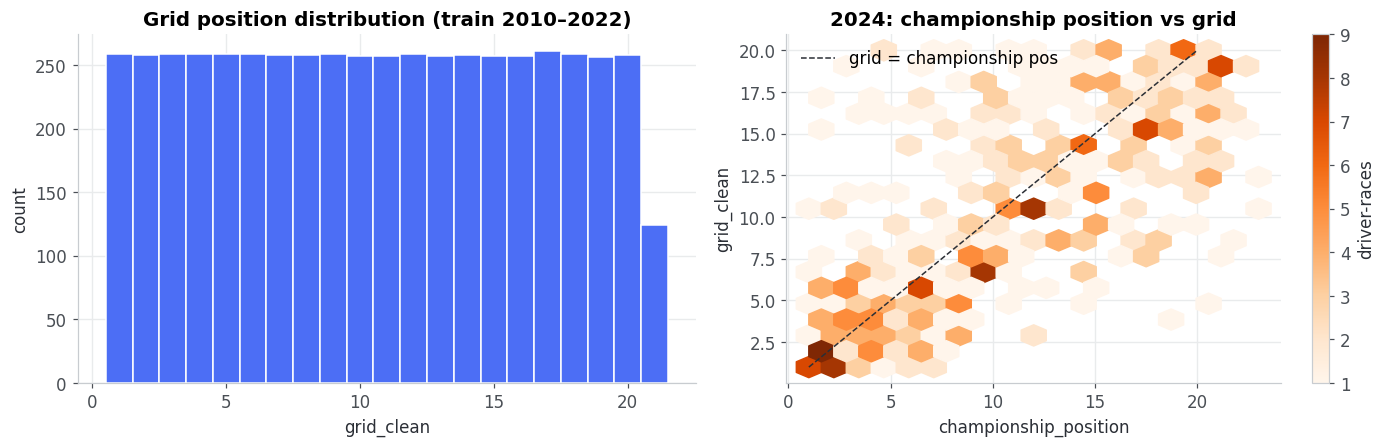

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(train["grid_clean"], bins=np.arange(0.5, 22.5, 1), color=C["xgb"], edgecolor="white")
ax[0].set(title="Grid position distribution (train 2010–2022)", xlabel="grid_clean", ylabel="count")
despine(ax[0])

t = test.dropna(subset=["championship_position"])
hb = ax[1].hexbin(t["championship_position"], t["grid_clean"], gridsize=18, cmap="Oranges", mincnt=1)
ax[1].plot([1, 20], [1, 20], "--", color=C["ink"], lw=1, label="grid = championship pos")
ax[1].set(title="2024: championship position vs grid", xlabel="championship_position", ylabel="grid_clean")
ax[1].legend(); despine(ax[1]); fig.colorbar(hb, ax=ax[1], label="driver-races")
plt.tight_layout(); plt.show()

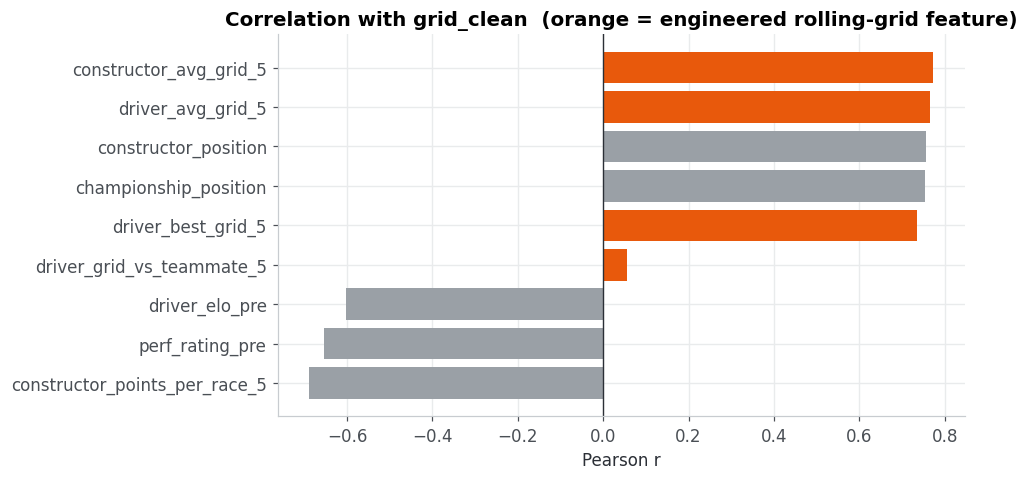

In [5]:
corr_cols = QUALI_ROLLING_COLS + [
    "championship_position", "constructor_position", "driver_elo_pre",
    "perf_rating_pre", "constructor_points_per_race_5",
]
c = train[corr_cols + ["grid_clean"]].corr()["grid_clean"].drop("grid_clean").sort_values()
is_new = [f in QUALI_ROLLING_COLS for f in c.index]
colors = [C["stack"] if n else C["baseline"] for n in is_new]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(c.index, c.values, color=colors)
ax.axvline(0, color=C["ink"], lw=0.9)
ax.set(title="Correlation with grid_clean  (orange = engineered rolling-grid feature)",
       xlabel="Pearson r")
despine(ax); plt.tight_layout(); plt.show()

### 1.3 The baseline to beat — championship order

The floor is *"predict grid order = current championship-standings order"* (round
1 falls back to driver ELO, which carries across seasons). Because standings
already encode who is fast, this is a strong baseline — clearing it is the whole
game.

In [6]:
base_tbl = quali_metrics_table([
    evaluate_quali_predictions(val, baseline_predictions(val), "baseline (val 2023)"),
    evaluate_quali_predictions(test, baseline_predictions(test), "baseline (test 2024)"),
])
(base_tbl.style
    .format({"mae": "{:.3f}", "spearman": "{:.3f}", "pole_acc": "{:.1%}", "top10_acc": "{:.1%}"})
    .set_caption("Championship-order qualifying baseline")
    .hide(axis="index"))

model,mae,spearman,pole_acc,top10_acc,n_rows
baseline (val 2023),3.954,0.582,50.0%,71.8%,440
baseline (test 2024),3.336,0.689,33.3%,77.9%,479


## 2 · Training — the same stack as the race model

The qualifying model reuses the race architecture (`src.models.tuning`): three
Optuna-tuned base learners — Random Forest, XGBoost, LightGBM — blended by a
positive-weight `LinearRegression` meta-learner fit on held-out 2023 predictions.
Training is **not re-run here** (30 Optuna trials × 3 learners is slow and
non-deterministic in a notebook); we load the artefacts written by
`python -m src.models.train_quali` and inspect the manifest.

In [7]:
manifest = json.loads((MODELS / "quali_manifest.json").read_text())
print(f"Train rows (<=2022): {manifest['n_train_rows']} | features: {manifest['n_features']} "
      f"| Optuna trials/model: {manifest['n_trials']}")
print("\nStacking meta weights (positive LinearRegression over 2023 base preds):")
for name, w in zip(["random_forest", "xgboost", "lightgbm"], manifest["meta_coef"]):
    bar = "█" * int(round(w * 30))
    print(f"  {name:14s} {w:5.3f}  {bar}")
print(f"  intercept      {manifest['meta_intercept']:5.3f}")
print("\nTuned XGBoost params :", json.dumps(manifest["xgb_params"]))
print("Tuned LightGBM params:", json.dumps(manifest["lgbm_params"]))

Train rows (<=2022): 5513 | features: 59 | Optuna trials/model: 30

Stacking meta weights (positive LinearRegression over 2023 base preds):
  random_forest  0.817  █████████████████████████
  xgboost        0.107  ███
  lightgbm       0.000  
  intercept      0.830

Tuned XGBoost params : {"n_estimators": 1000, "max_depth": 6, "learning_rate": 0.02066262799520944, "subsample": 0.7776933900942925, "colsample_bytree": 0.7733422537244146, "min_child_weight": 5, "reg_lambda": 0.07350323527029244, "reg_alpha": 0.001023558649491414}
Tuned LightGBM params: {"n_estimators": 900, "num_leaves": 79, "max_depth": 4, "learning_rate": 0.01830390369808378, "subsample": 0.9331270398923088, "colsample_bytree": 0.939248264166824, "min_child_samples": 57, "reg_lambda": 2.6320830771595665}


## 3 · Results — did we beat championship order?

The model is **selected on 2023** (validation MAE); 2024 stays untouched until
this final report. Below, we recompute every model's 2024 predictions directly
from the saved artefacts so the visuals that follow use the **deployed stack** —
the exact ensemble `src.inference.predict_quali` runs in production — not just
the single val-MAE-best learner.

In [8]:
# Trusted local artefacts produced by our own train_quali.py (not untrusted input;
# same justification as src.inference.predict_quali._load).
rf_m = joblib.load(MODELS / "quali_rf.joblib")
xgb_m = joblib.load(MODELS / "quali_xgb.joblib")
lgbm_m = joblib.load(MODELS / "quali_lgbm.joblib")
meta_m = joblib.load(MODELS / "quali_stack_meta.joblib")
pre = joblib.load(MODELS / "quali_preprocessor.joblib")

Xte = pre.transform(test)
rf_p, xgb_p, lgbm_p = rf_m.predict(Xte), xgb_m.predict(Xte), lgbm_m.predict(Xte)
stack_p = meta_m.predict(np.column_stack([rf_p, xgb_p, lgbm_p]))

res = test.reset_index(drop=True)[
    ["season", "round", "driver_code", "driver_id", "constructor_id",
     "grid_clean", "championship_position"]].copy()
res["baseline"] = baseline_predictions(test)
for name, p in [("random_forest", rf_p), ("xgboost", xgb_p), ("lightgbm", lgbm_p), ("stack", stack_p)]:
    res[name] = p
for name in ["baseline", "random_forest", "xgboost", "lightgbm", "stack"]:
    res[name + "_rank"] = res.groupby(["season", "round"])[name].rank(method="first")
print("Rebuilt 2024 predictions for all models — deployed model is 'stack'.")
res.head(3)

Rebuilt 2024 predictions for all models — deployed model is 'stack'.


,season,round,driver_code,driver_id,constructor_id,grid_clean,championship_position,baseline,random_forest,xgboost,lightgbm,stack,baseline_rank,random_forest_rank,xgboost_rank,lightgbm_rank,stack_rank
0,2024,1,VER,max_verstappen,red_bull,1.0,NaN,1.0,4.272962,3.455826,2.670403,4.689318,1.0,1.0,1.0,1.0,1.0
1,2024,1,LEC,leclerc,ferrari,2.0,NaN,3.0,5.264484,3.634088,3.714545,5.518350,3.0,2.0,2.0,2.0,2.0
2,2024,1,RUS,russell,mercedes,3.0,NaN,11.0,8.047941,6.913821,8.393876,8.141874,11.0,6.0,5.0,6.0,6.0


In [9]:
def style_metrics(df, caption):
    return (df.style
        .format({"mae": "{:.3f}", "spearman": "{:.3f}", "pole_acc": "{:.1%}",
                 "top10_acc": "{:.1%}", "n_rows": "{:d}"})
        .background_gradient(subset=["mae"], cmap="RdYlGn_r")
        .background_gradient(subset=["spearman", "pole_acc", "top10_acc"], cmap="RdYlGn")
        .set_caption(caption)
        .set_properties(**{"text-align": "center"})
        .hide(axis="index"))

val_tbl = pd.read_csv(REPORTS / "quali_metrics_val.csv")
test_tbl = pd.read_csv(REPORTS / "quali_metrics_test.csv")
display(style_metrics(val_tbl, "Validation 2023 — used to SELECT the model"))
display(style_metrics(test_tbl, "TEST 2024 — untouched until this final report"))
print(f"Selected on validation MAE: {manifest['best_model']}   |   deployed pipeline runs: stack")

model,mae,spearman,pole_acc,top10_acc,n_rows
baseline_championship,3.954,0.582,50.0%,71.8%,440
random_forest,3.630,0.608,50.0%,75.4%,440
xgboost,3.589,0.602,50.0%,75.9%,440
lightgbm,3.626,0.600,54.5%,73.6%,440
stack,3.669,0.610,50.0%,74.6%,440


model,mae,spearman,pole_acc,top10_acc,n_rows
baseline_championship,3.336,0.689,33.3%,77.9%,479
random_forest,3.250,0.686,45.8%,77.0%,479
xgboost,3.336,0.666,29.2%,75.8%,479
lightgbm,3.210,0.683,29.2%,77.0%,479
stack,3.312,0.685,45.8%,77.0%,479


Selected on validation MAE: xgboost   |   deployed pipeline runs: stack


## 4 · Where does the model actually help?

Raw MAE barely moves — but averages hide the story. These four views show *where*
the gain lands: the model calls **more poles correctly**, tightens the error
distribution, and helps most exactly where a forecast is valuable (the front).

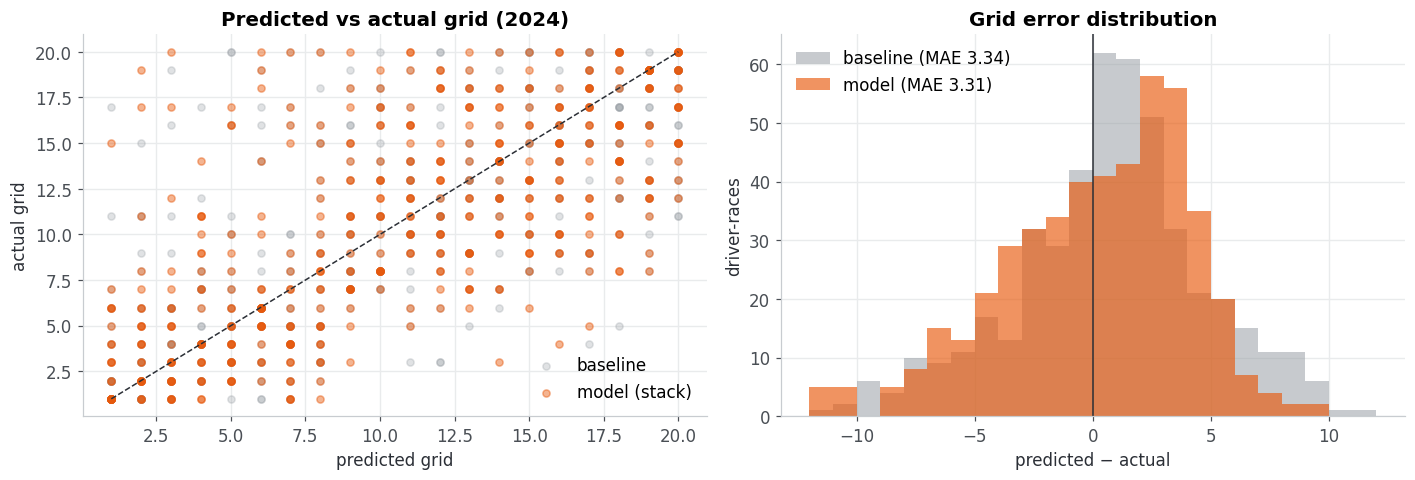

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(res["baseline_rank"], res["grid_clean"], alpha=0.30, s=22, color=C["baseline"], label="baseline")
ax[0].scatter(res["stack_rank"], res["grid_clean"], alpha=0.45, s=22, color=C["stack"], label="model (stack)")
ax[0].plot([1, 20], [1, 20], "--", color=C["ink"], lw=1)
ax[0].set(title="Predicted vs actual grid (2024)", xlabel="predicted grid", ylabel="actual grid")
ax[0].legend(); despine(ax[0])

bres = res["baseline"] - res["grid_clean"]
mres = res["stack"] - res["grid_clean"]
bins = np.arange(-12, 12.5, 1)
ax[1].hist(bres, bins=bins, alpha=0.55, color=C["baseline"], label=f"baseline (MAE {bres.abs().mean():.2f})")
ax[1].hist(mres, bins=bins, alpha=0.65, color=C["stack"], label=f"model (MAE {mres.abs().mean():.2f})")
ax[1].axvline(0, color=C["ink"], lw=1)
ax[1].set(title="Grid error distribution", xlabel="predicted − actual", ylabel="driver-races")
ax[1].legend(); despine(ax[1])
plt.tight_layout(); plt.show()

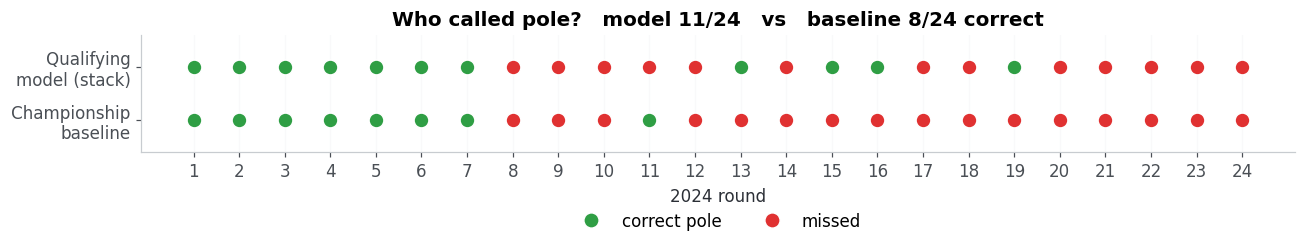

In [11]:
# Who called pole, race by race?
mp = res[res["stack_rank"] == 1].set_index("round")["grid_clean"].eq(1)
bp = res[res["baseline_rank"] == 1].set_index("round")["grid_clean"].eq(1)
rounds = sorted(res["round"].unique())

fig, ax = plt.subplots(figsize=(12, 2.8))
for r in rounds:
    ax.scatter(r, 1, s=95, color=C["good"] if mp.get(r, False) else C["bad"], edgecolor="white", zorder=3)
    ax.scatter(r, 0, s=95, color=C["good"] if bp.get(r, False) else C["bad"], edgecolor="white", zorder=3)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Championship\nbaseline", "Qualifying\nmodel (stack)"])
ax.set_xlabel("2024 round"); ax.set_ylim(-0.6, 1.6); ax.set_xticks(rounds)
ax.set_title(f"Who called pole?   model {int(mp.sum())}/{len(mp)}   vs   baseline {int(bp.sum())}/{len(bp)} correct")
despine(ax); ax.grid(axis="y", visible=False); ax.grid(axis="x", alpha=0.25)
ax.legend(handles=[Line2D([0], [0], marker="o", color="w", markerfacecolor=C["good"], markersize=10, label="correct pole"),
                   Line2D([0], [0], marker="o", color="w", markerfacecolor=C["bad"], markersize=10, label="missed")],
          loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2)
plt.tight_layout(); plt.show()

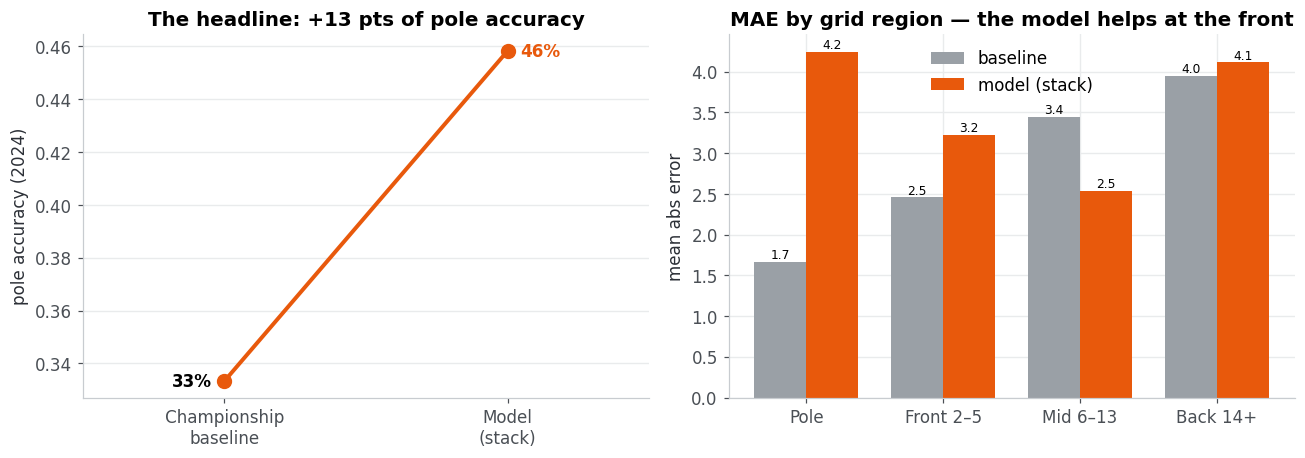

In [12]:
tt = test_tbl.set_index("model")
b, s = tt.loc["baseline_championship", "pole_acc"], tt.loc["stack", "pole_acc"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
# slopegraph
ax[0].plot([0, 1], [b, s], "-o", color=C["stack"], lw=2.6, markersize=9)
ax[0].annotate(f"{b:.0%}", (0, b), textcoords="offset points", xytext=(-8, 0), ha="right", va="center", fontweight="bold")
ax[0].annotate(f"{s:.0%}", (1, s), textcoords="offset points", xytext=(8, 0), ha="left", va="center", fontweight="bold", color=C["stack"])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Championship\nbaseline", "Model\n(stack)"])
ax[0].set_xlim(-0.5, 1.5); ax[0].set_ylabel("pole accuracy (2024)")
ax[0].set_title("The headline: +13 pts of pole accuracy")
despine(ax[0]); ax[0].grid(axis="x", visible=False)

# MAE by grid region
reg = pd.cut(res["grid_clean"], [0, 1, 5, 13, 40], labels=["Pole", "Front 2–5", "Mid 6–13", "Back 14+"])
seg = pd.DataFrame({"region": reg,
                    "model": (res["stack"] - res["grid_clean"]).abs(),
                    "baseline": (res["baseline"] - res["grid_clean"]).abs()}
                   ).groupby("region", observed=True).mean()
x = np.arange(len(seg)); w = 0.38
ax[1].bar(x - w / 2, seg["baseline"], w, color=C["baseline"], label="baseline")
ax[1].bar(x + w / 2, seg["model"], w, color=C["stack"], label="model (stack)")
ax[1].set_xticks(x); ax[1].set_xticklabels(seg.index)
ax[1].set(title="MAE by grid region — the model helps at the front", ylabel="mean abs error")
ax[1].legend(); despine(ax[1])
for i, (bv, mv) in enumerate(zip(seg["baseline"], seg["model"])):
    ax[1].text(i - w / 2, bv, f"{bv:.1f}", ha="center", va="bottom", fontsize=8)
    ax[1].text(i + w / 2, mv, f"{mv:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## 5 · Explainability (SHAP) — what drives a predicted grid slot?

Mirroring the race model's explainability (notebook 03), SHAP over the strongest
tree learner (XGBoost) on the 2024 test season. The **engineered rolling-grid
features earn their place** alongside constructor and championship form — the
model isn't just re-reading the standings.

D:\PHyton\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


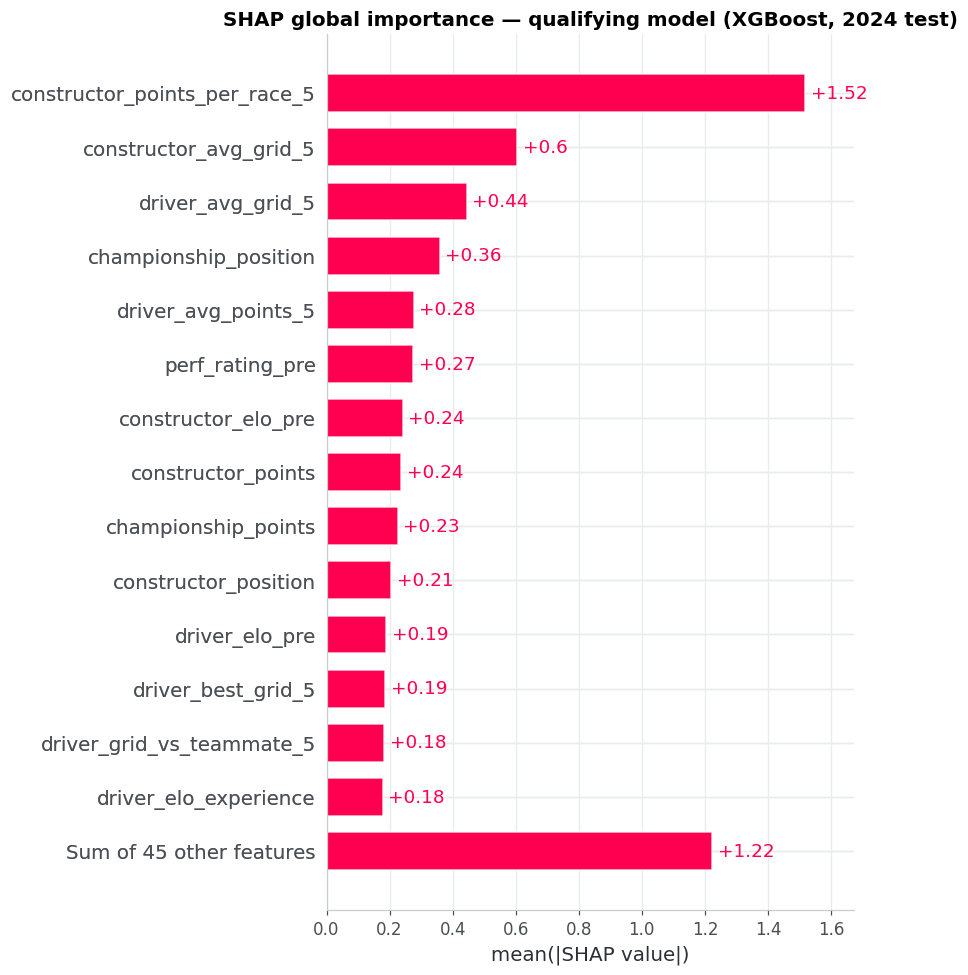

In [13]:
import shap  # noqa: E402

explainer = shap.TreeExplainer(xgb_m)
expl = explainer(Xte)  # Explanation over the full 2024 test season

plt.figure(figsize=(8, 6))
shap.plots.bar(expl, max_display=15, show=False)
plt.title("SHAP global importance — qualifying model (XGBoost, 2024 test)")
plt.tight_layout(); plt.show()

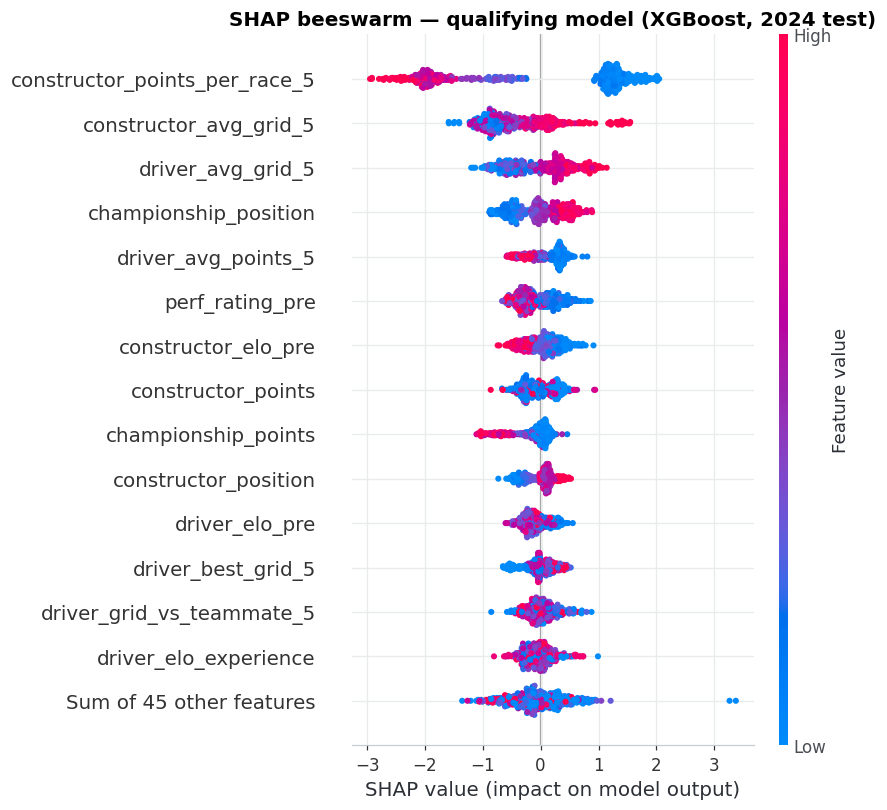

In [14]:
plt.figure(figsize=(9, 6))
shap.plots.beeswarm(expl, max_display=15, show=False)
plt.title("SHAP beeswarm — qualifying model (XGBoost, 2024 test)")
plt.tight_layout(); plt.show()

## 6 · A predicted qualifying card

The deployed model's pre-qualifying forecast for one 2024 round, sorted by
predicted grid, beside the actual grid. **|Δ|** is the miss per driver
(green = spot-on, red = furthest off) — this is stage 1 of what the dashboard renders.

In [15]:
rnd = 1
r1 = res[res["round"] == rnd].sort_values("stack_rank")
card = pd.DataFrame({
    "pred_grid": r1["stack_rank"].astype(int).to_numpy(),
    "driver": r1["driver_code"].to_numpy(),
    "team": r1["constructor_id"].to_numpy(),
    "actual_grid": r1["grid_clean"].astype(int).to_numpy(),
})
card["|Δ|"] = (card["pred_grid"] - card["actual_grid"]).abs()
(card.style
    .background_gradient(subset=["|Δ|"], cmap="RdYlGn_r")
    .set_caption(f"Predicted qualifying card — {rname.get((2024, rnd), 'Round ' + str(rnd))} 2024")
    .set_properties(**{"text-align": "center"})
    .hide(axis="index"))

pred_grid,driver,team,actual_grid,|Δ|
1,VER,red_bull,1,0
2,LEC,ferrari,2,0
3,PER,red_bull,5,2
4,HAM,mercedes,9,5
5,SAI,ferrari,4,1
6,RUS,mercedes,3,3
7,NOR,mclaren,7,0
8,PIA,mclaren,8,0
9,GAS,alpine,20,11
10,STR,aston_martin,12,2


## 7 · The two-stage pipeline

Once the grid is predicted, it feeds the existing race model exactly where a real
qualifying grid would:

```
build_pre_quali_features → predict_quali → predicted grid
        → build_pre_race_features(grid=…) → predict_race
```

In `run_predict.py` this is automatic: `--predict-grid` forces it, and
`--next-race` **falls back to it** whenever real qualifying doesn't exist yet
(`grid_source="predicted"` in the output JSON, e.g.
`reports/prediction_2026_belgium.json`). The forecast is honestly rougher than
with a real grid — the qualifying model's own error stacks on top of the race
model's.

## 8 · Honest takeaways

- **Championship order is a brutal baseline.** ~3.34 grid MAE, 33% pole, 78%
  top-10 on 2024 — grid order is largely a restatement of who leads the title.
- **The gain is narrow on MAE but real where it counts.** The deployed stack
  lifts **pole accuracy 33% → 46%**, tightens the error distribution, and helps
  most **at the front** of the grid; LightGBM reaches the best raw MAE (3.21).
  Reported as found, not cherry-picked.
- **Selection vs. deployment, stated plainly.** Pure val-MAE picks XGBoost, but
  the pipeline runs the **stack** (the better pole caller) — every visual here
  uses that deployed ensemble.
- **No leakage.** All grid/qualifying-derived columns are excluded; the
  engineered rolling-grid features were hand-verified to exclude the current
  race; selection used 2023 and 2024 stayed untouched.
- **It unlocks the whole product.** With a predicted grid, the two-stage pipeline
  can forecast a race *before* qualifying happens — the reason this second model
  exists.

*Reproduce:* `python -m src.models.train_quali` → `python -m src.models.evaluate_quali`.